In [30]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [31]:
def ProfitLoss(DataC):
    DataC = np.array(DataC)
    changelist = []
    profit = []
    losses = []

    for i in range(len(DataC) - 1):
        changelist.append(DataC[i + 1] - DataC[i])

    for k in changelist:
        if k > 0:
            profit.append(round(k, 2))
        else:
            profit.append(0)

    for j in changelist:
        if j < 0:
            losses.append(abs(round(j, 2)))
        else:
            losses.append(0)

    return [profit, losses]

In [32]:
def AverageProfitLoss(days, DataC):
    DataC = np.array(DataC)
    AverageGains = []
    avg = DataC[:days].mean()
    AverageGains.append(round(avg, 2))
    prevavggain = avg

    for i in range(days, len(DataC)):
        avggainval = ((prevavggain * (days - 1)) + DataC[i]) / days
        prevavggain = avggainval
        AverageGains.append(round(avggainval, 2))

    return AverageGains

In [36]:
data = yf.download('AAPL', start='2021-05-23', end='2023-05-23', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [37]:
VolUp = ProfitLoss(data['Volume'])[0]
VolDown = ProfitLoss(data['Volume'])[1]
AvgVolUp = AverageProfitLoss(14, VolUp)
AvgVolDown = AverageProfitLoss(14, VolDown)
VRS = [round(x / y, 2) for x, y in zip(AvgVolUp, AvgVolDown)]
VRSI = [round((100 - (100) / (1 + vrs)), 2) for vrs in VRS]

Text(0, 0.5, 'VRSI Indicator')

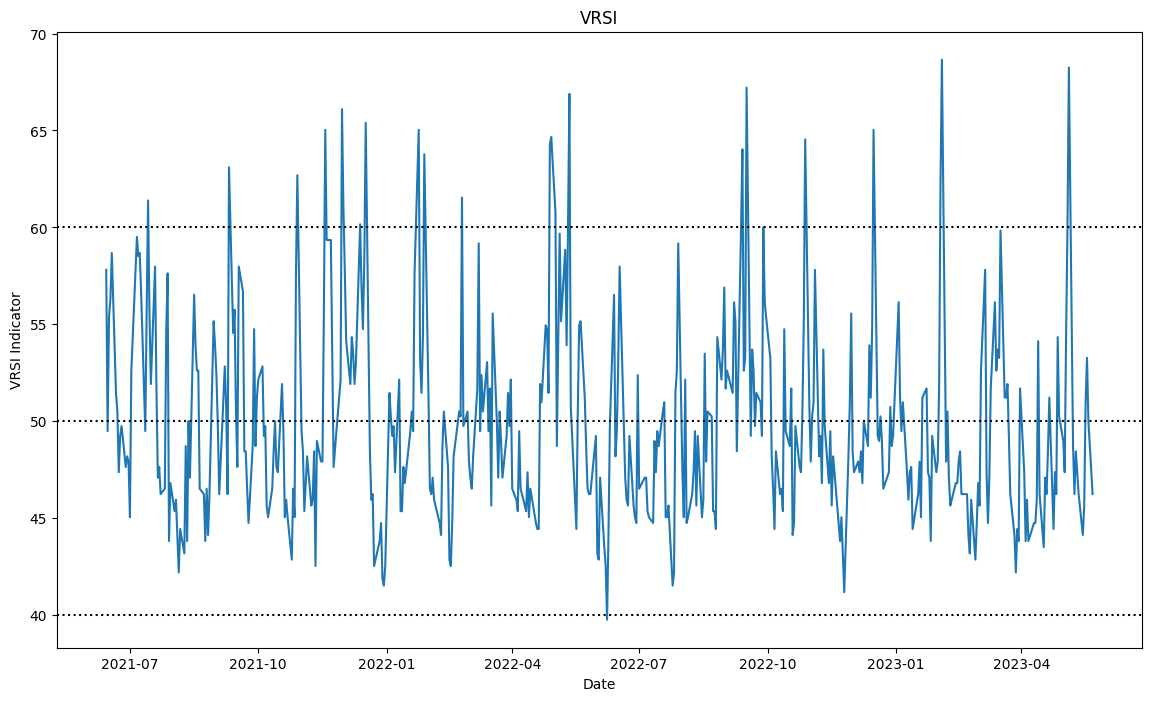

In [38]:
plt.figure(figsize=(14, 8))
plt.plot(data.index[14:], VRSI)
plt.axhline(50, color='black', linestyle='dotted')
plt.axhline(60, color='black', linestyle='dotted')
plt.axhline(40, color='black', linestyle='dotted')
plt.title('VRSI')
plt.xlabel('Date')
plt.ylabel('VRSI Indicator')